# Chapter 10

Add your content here.

Generating Ground Truth Image...
Visualizing Next-Scale Prediction Steps:


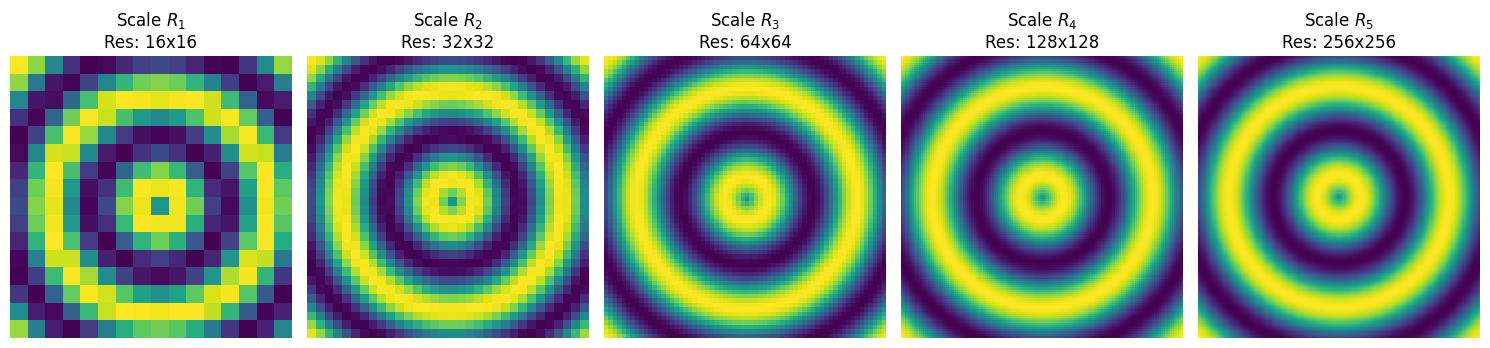

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_image(size=256):
    """
    Creates a synthetic image with a simple pattern (concentric circles).
    This represents our 'Ground Truth' high-resolution image.
    """
    x = np.linspace(-10, 10, size)
    y = np.linspace(-10, 10, size)
    X, Y = np.meshgrid(x, y)
    
    # Create a pattern: sin(distance)
    R = np.sqrt(X**2 + Y**2)
    Z = np.sin(R)
    
    # Normalize to 0-1 for visualization
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    return Z

def create_var_pyramid(image, levels):
    """
    Simulates the VAR Encoding process.
    We create a pyramid of scales, R1 to R_K.
    In a real VAR, this is done by a VQ-VAE. Here, we use simple resizing.
    """
    pyramid = []
    current_size = image.shape[0]
    
    # We work backwards from high res to low res to build the pyramid targets
    for i in range(levels):
        scale_factor = 2 ** (levels - 1 - i) # e.g., 32, 16, 8, ...
        target_size = current_size // scale_factor
        
        # Simple block averaging to simulate downsampling
        # (In real VAR, this is a learnable convolution)
        downsampled = image[::scale_factor, ::scale_factor]
        pyramid.append(downsampled)
        
    return pyramid # [R1 (smallest), R2, ..., R_K (largest)]

def simulate_autoregressive_generation(pyramid):
    """
    Simulates the generation process: P(R_k | R_<k).
    We visualize 'Predicting' the next scale.
    """
    plt.figure(figsize=(15, 5))
    
    for i, scale_map in enumerate(pyramid):
        # In a real model, 'scale_map' is PREDICTED by the Neural Net.
        # Here, we just reveal the ground truth to show the structure.
        
        resolution = scale_map.shape[0]
        
        plt.subplot(1, len(pyramid), i + 1)
        plt.imshow(scale_map, cmap='viridis', interpolation='nearest')
        plt.title(f"Scale $R_{i+1}$\nRes: {resolution}x{resolution}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- Execution ---

# 1. Create Data
print("Generating Ground Truth Image...")
ground_truth = generate_synthetic_image(size=256)

# 2. Encode into VAR Pyramid (Simulating the VQ-VAE)
# We want scales: 16x16, 32x32, 64x64, 128x128, 256x256
levels = 5 
feature_pyramid = create_var_pyramid(ground_truth, levels)

# 3. Simulate the Generation Process
print("Visualizing Next-Scale Prediction Steps:")
simulate_autoregressive_generation(feature_pyramid)